# Customer Segmentation & Churn Pattern Analytics in European Banking

## Notebook 05: Machine Learning Model Development

### Objective

This notebook develops and compares multiple classification models for predicting customer churn.

The workflow includes:

- Loading the preprocessed training and testing datasets
- Verifying feature and target consistency
- Establishing a majority-class baseline
- Training multiple machine-learning models
- Evaluating churn prediction performance
- Comparing original-data, class-weighted, and SMOTE-based approaches
- Selecting candidate models for detailed evaluation and deployment

### Target Variable

- `Exited = 0`: Retained customer
- `Exited = 1`: Churned customer

Because the churn class represents approximately 20% of customers, model selection will focus on:

- Recall for churned customers
- Precision
- F1-score
- ROC-AUC
- PR-AUC
- Balanced accuracy

Accuracy alone will not be used to select the final model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
current_directory = Path.cwd()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_directory = project_root / "data"
processed_directory = data_directory / "processed"
model_directory = project_root / "models"
output_directory = project_root / "outputs"
table_directory = output_directory / "tables"
chart_directory = output_directory / "charts"

for folder in [
    processed_directory,
    model_directory,
    table_directory,
    chart_directory
]:
    folder.mkdir(parents=True, exist_ok=True)

x_train_path = processed_directory / "X_train.csv"
x_test_path = processed_directory / "X_test.csv"
y_train_path = processed_directory / "y_train.csv"
y_test_path = processed_directory / "y_test.csv"

print("Project root       :", project_root)
print("Processed data dir :", processed_directory)
print("Model directory    :", model_directory)

Project root       : d:\Customer_Segmentation_Churn_Banking
Processed data dir : d:\Customer_Segmentation_Churn_Banking\data\processed
Model directory    : d:\Customer_Segmentation_Churn_Banking\models


In [3]:
required_files = [
    x_train_path,
    x_test_path,
    y_train_path,
    y_test_path
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following processed files are missing:\n"
        + "\n".join(missing_files)
        + "\nComplete Notebook 04 before running Notebook 05."
    )

X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)

y_train = pd.read_csv(y_train_path).squeeze("columns")
y_test = pd.read_csv(y_test_path).squeeze("columns")

y_train = pd.to_numeric(
    y_train,
    errors="raise"
).astype(int)

y_test = pd.to_numeric(
    y_test,
    errors="raise"
).astype(int)

print("Processed datasets loaded successfully.")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Processed datasets loaded successfully.
X_train: (8000, 17)
X_test : (2000, 17)
y_train: (8000,)
y_test : (2000,)


In [4]:
print("=" * 70)
print("MODEL DEVELOPMENT DATASET VALIDATION")
print("=" * 70)

print(f"Training feature rows     : {len(X_train):,}")
print(f"Training target rows      : {len(y_train):,}")
print(f"Testing feature rows      : {len(X_test):,}")
print(f"Testing target rows       : {len(y_test):,}")

print(
    f"\nTraining missing values  : "
    f"{X_train.isna().sum().sum():,}"
)

print(
    f"Testing missing values   : "
    f"{X_test.isna().sum().sum():,}"
)

print(
    f"Training target missing  : "
    f"{y_train.isna().sum():,}"
)

print(
    f"Testing target missing   : "
    f"{y_test.isna().sum():,}"
)

print(
    f"\nFeature columns identical: "
    f"{X_train.columns.equals(X_test.columns)}"
)

print(
    f"All training values finite: "
    f"{np.isfinite(X_train.to_numpy()).all()}"
)

print(
    f"All testing values finite : "
    f"{np.isfinite(X_test.to_numpy()).all()}"
)

print(
    f"Valid training target     : "
    f"{set(y_train.unique()).issubset({0, 1})}"
)

print(
    f"Valid testing target      : "
    f"{set(y_test.unique()).issubset({0, 1})}"
)

MODEL DEVELOPMENT DATASET VALIDATION
Training feature rows     : 8,000
Training target rows      : 8,000
Testing feature rows      : 2,000
Testing target rows       : 2,000

Training missing values  : 0
Testing missing values   : 0
Training target missing  : 0
Testing target missing   : 0

Feature columns identical: True
All training values finite: True
All testing values finite : True
Valid training target     : True
Valid testing target      : True


In [5]:
if len(X_train) != len(y_train):
    raise ValueError(
        "Training feature and target row counts do not match."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "Testing feature and target row counts do not match."
    )

if not X_train.columns.equals(X_test.columns):
    raise ValueError(
        "Training and testing feature columns are inconsistent."
    )

if X_train.isna().sum().sum() > 0:
    raise ValueError(
        "Missing values detected in X_train."
    )

if X_test.isna().sum().sum() > 0:
    raise ValueError(
        "Missing values detected in X_test."
    )

if not np.isfinite(X_train.to_numpy()).all():
    raise ValueError(
        "Infinite values detected in X_train."
    )

if not np.isfinite(X_test.to_numpy()).all():
    raise ValueError(
        "Infinite values detected in X_test."
    )

print("\nValidation passed successfully.")


Validation passed successfully.


In [6]:
def create_target_distribution(
    target,
    dataset_name
):
    counts = (
        target
        .value_counts()
        .sort_index()
    )

    percentages = (
        target
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    result = pd.DataFrame({
        "Dataset": dataset_name,
        "Exited": counts.index,
        "Customers": counts.values,
        "Percentage": percentages.values
    })

    return result


train_target_distribution = create_target_distribution(
    y_train,
    "Training"
)

test_target_distribution = create_target_distribution(
    y_test,
    "Testing"
)

target_distribution_summary = pd.concat(
    [
        train_target_distribution,
        test_target_distribution
    ],
    ignore_index=True
)

target_distribution_summary

,Dataset,Exited,Customers,Percentage
0,Training,0,6370,79.62
1,Training,1,1630,20.38
2,Testing,0,1593,79.65
3,Testing,1,407,20.35


In [7]:
target_distribution_summary.to_csv(
    table_directory /
    "model_target_distribution.csv",
    index=False
)

print("Target-distribution summary saved.")

Target-distribution summary saved.


In [8]:
majority_class = int(
    y_train.mode().iloc[0]
)

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        baseline_predictions
    )
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print("=" * 65)
print("MAJORITY-CLASS BASELINE")
print("=" * 65)

print(f"Majority class       : {majority_class}")
print(f"Accuracy             : {baseline_accuracy:.4f}")
print(
    f"Balanced accuracy    : "
    f"{baseline_balanced_accuracy:.4f}"
)
print(f"Churn precision      : {baseline_precision:.4f}")
print(f"Churn recall         : {baseline_recall:.4f}")
print(f"Churn F1-score       : {baseline_f1:.4f}")

MAJORITY-CLASS BASELINE
Majority class       : 0
Accuracy             : 0.7965
Balanced accuracy    : 0.5000
Churn precision      : 0.0000
Churn recall         : 0.0000
Churn F1-score       : 0.0000


In [9]:
def evaluate_classifier(
    model_name,
    model,
    X_train_data,
    y_train_data,
    X_test_data,
    y_test_data,
    training_strategy="Original"
):
    """
    Train and evaluate one binary classification model.
    """

    fitted_model = clone(model)

    fitted_model.fit(
        X_train_data,
        y_train_data
    )

    predictions = fitted_model.predict(
        X_test_data
    )

    if hasattr(
        fitted_model,
        "predict_proba"
    ):
        probabilities = (
            fitted_model.predict_proba(
                X_test_data
            )[:, 1]
        )

    elif hasattr(
        fitted_model,
        "decision_function"
    ):
        decision_scores = (
            fitted_model.decision_function(
                X_test_data
            )
        )

        score_min = decision_scores.min()
        score_max = decision_scores.max()

        probabilities = (
            decision_scores - score_min
        ) / (
            score_max - score_min + 1e-12
        )

    else:
        probabilities = predictions.astype(float)

    tn, fp, fn, tp = confusion_matrix(
        y_test_data,
        predictions,
        labels=[0, 1]
    ).ravel()

    result = {
        "Model": model_name,
        "Training_Strategy": training_strategy,
        "Accuracy": accuracy_score(
            y_test_data,
            predictions
        ),
        "Balanced_Accuracy": (
            balanced_accuracy_score(
                y_test_data,
                predictions
            )
        ),
        "Precision_Churn": precision_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "Recall_Churn": recall_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "F1_Churn": f1_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test_data,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_test_data,
            probabilities
        ),
        "True_Negatives": int(tn),
        "False_Positives": int(fp),
        "False_Negatives": int(fn),
        "True_Positives": int(tp)
    }

    return {
        "result": result,
        "model": fitted_model,
        "predictions": predictions,
        "probabilities": probabilities
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [10]:
models_original = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

print("Models defined:")

for model_name in models_original:
    print(f"- {model_name}")

Models defined:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Extra Trees


In [11]:
original_results = []
original_fitted_models = {}
original_predictions = {}
original_probabilities = {}

for model_name, model in models_original.items():
    print(f"Training: {model_name}")

    evaluation_output = evaluate_classifier(
        model_name=model_name,
        model=model,
        X_train_data=X_train,
        y_train_data=y_train,
        X_test_data=X_test,
        y_test_data=y_test,
        training_strategy="Original"
    )

    original_results.append(
        evaluation_output["result"]
    )

    original_fitted_models[model_name] = (
        evaluation_output["model"]
    )

    original_predictions[model_name] = (
        evaluation_output["predictions"]
    )

    original_probabilities[model_name] = (
        evaluation_output["probabilities"]
    )

print("\nAll original-data models trained successfully.")

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: Extra Trees

All original-data models trained successfully.


In [12]:
original_model_comparison = pd.DataFrame(
    original_results
)

metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision_Churn",
    "Recall_Churn",
    "F1_Churn",
    "ROC_AUC",
    "PR_AUC"
]

original_model_comparison[
    metric_columns
] = original_model_comparison[
    metric_columns
].round(4)

original_model_comparison = (
    original_model_comparison
    .sort_values(
        by=[
            "ROC_AUC",
            "F1_Churn"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

original_model_comparison

,Model,Training_Strategy,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Gradient Boosting,Original,0.8660,0.7174,0.7884,0.4668,0.5864,0.8703,0.7163,1542,51,217,190
1,Random Forest,Original,0.8625,0.7143,0.7683,0.4644,0.5789,0.8490,0.6873,1536,57,218,189
2,Decision Tree,Original,0.8535,0.6968,0.7395,0.4324,0.5457,0.8466,0.6471,1531,62,231,176
3,Extra Trees,Original,0.8560,0.7111,0.7280,0.4668,0.5689,0.8431,0.6616,1522,71,217,190
4,Logistic Regression,Original,0.8065,0.5758,0.5758,0.1867,0.2820,0.7751,0.4807,1537,56,331,76


In [13]:
original_model_comparison.to_csv(
    table_directory /
    "original_model_comparison.csv",
    index=False
)

print("Original-model comparison saved.")

Original-model comparison saved.


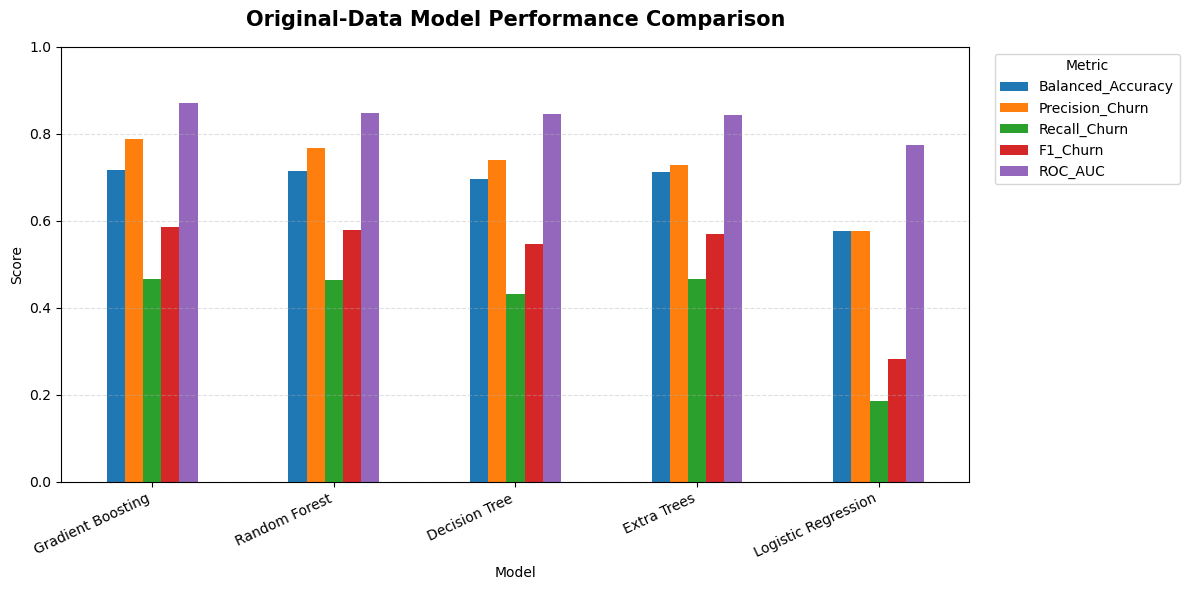

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\40_original_model_performance_comparison.png


In [14]:
comparison_chart_data = (
    original_model_comparison
    .set_index("Model")
    [
        [
            "Balanced_Accuracy",
            "Precision_Churn",
            "Recall_Churn",
            "F1_Churn",
            "ROC_AUC"
        ]
    ]
)

ax = comparison_chart_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Original-Data Model Performance Comparison",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "40_original_model_performance_comparison.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

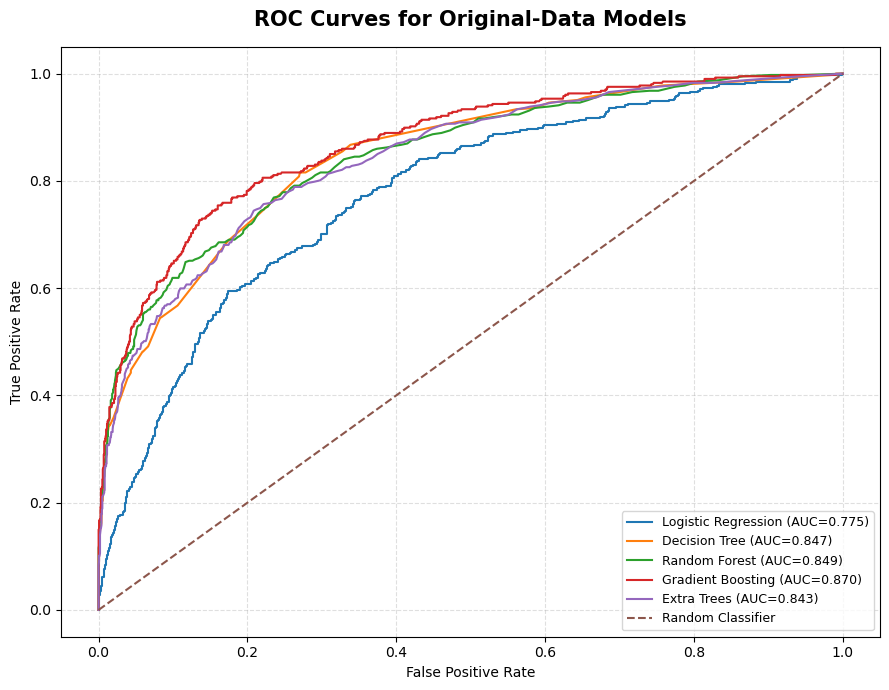

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\41_original_model_roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, probabilities in (
    original_probabilities.items()
):
    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_test,
            probabilities
        )
    )

    model_auc = roc_auc_score(
        y_test,
        probabilities
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{model_name} "
            f"(AUC={model_auc:.3f})"
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

ax.set_title(
    "ROC Curves for Original-Data Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(
    loc="lower right",
    fontsize=9
)

ax.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "41_original_model_roc_curves.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

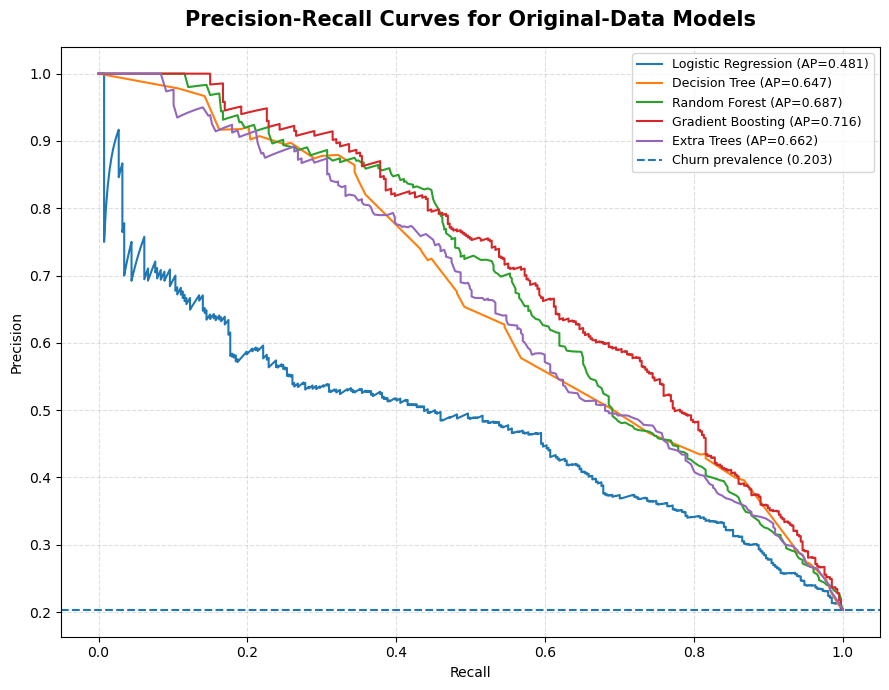

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\42_original_model_precision_recall_curves.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, probabilities in (
    original_probabilities.items()
):
    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_test,
            probabilities
        )
    )

    model_pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    ax.plot(
        recall_values,
        precision_values,
        label=(
            f"{model_name} "
            f"(AP={model_pr_auc:.3f})"
        )
    )

baseline_positive_rate = y_test.mean()

ax.axhline(
    baseline_positive_rate,
    linestyle="--",
    label=(
        "Churn prevalence "
        f"({baseline_positive_rate:.3f})"
    )
)

ax.set_title(
    "Precision-Recall Curves for Original-Data Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(
    loc="upper right",
    fontsize=9
)

ax.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "42_original_model_precision_recall_curves.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [17]:
best_original_row = (
    original_model_comparison
    .sort_values(
        by=[
            "ROC_AUC",
            "F1_Churn",
            "Recall_Churn"
        ],
        ascending=False
    )
    .iloc[0]
)

best_original_model_name = (
    best_original_row["Model"]
)

best_original_model = (
    original_fitted_models[
        best_original_model_name
    ]
)

print("=" * 65)
print("LEADING ORIGINAL-DATA MODEL")
print("=" * 65)

print(
    f"Model              : "
    f"{best_original_model_name}"
)

print(
    f"Accuracy           : "
    f"{best_original_row['Accuracy']:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{best_original_row['Balanced_Accuracy']:.4f}"
)

print(
    f"Precision - Churn  : "
    f"{best_original_row['Precision_Churn']:.4f}"
)

print(
    f"Recall - Churn     : "
    f"{best_original_row['Recall_Churn']:.4f}"
)

print(
    f"F1 - Churn         : "
    f"{best_original_row['F1_Churn']:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{best_original_row['ROC_AUC']:.4f}"
)

print(
    f"PR-AUC             : "
    f"{best_original_row['PR_AUC']:.4f}"
)

LEADING ORIGINAL-DATA MODEL
Model              : Gradient Boosting
Accuracy           : 0.8660
Balanced Accuracy  : 0.7174
Precision - Churn  : 0.7884
Recall - Churn     : 0.4668
F1 - Churn         : 0.5864
ROC-AUC            : 0.8703
PR-AUC             : 0.7163


In [18]:
best_original_predictions = (
    original_predictions[
        best_original_model_name
    ]
)

best_original_classification_report = (
    classification_report(
        y_test,
        best_original_predictions,
        target_names=[
            "Retained",
            "Churned"
        ],
        output_dict=True,
        zero_division=0
    )
)

best_original_report_df = (
    pd.DataFrame(
        best_original_classification_report
    )
    .T
    .round(4)
)

best_original_report_df

,precision,recall,f1-score,support
Retained,0.8766,0.9680,0.9200,1593.000
Churned,0.7884,0.4668,0.5864,407.000
accuracy,0.8660,0.8660,0.8660,0.866
macro avg,0.8325,0.7174,0.7532,2000.000
weighted avg,0.8587,0.8660,0.8522,2000.000


In [19]:
best_original_report_df.to_csv(
    table_directory /
    "best_original_model_classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


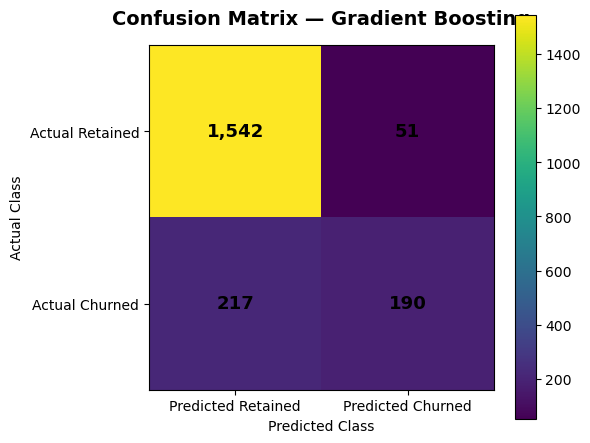

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\43_best_original_model_confusion_matrix.png


In [20]:
best_original_confusion_matrix = (
    confusion_matrix(
        y_test,
        best_original_predictions,
        labels=[0, 1]
    )
)

fig, ax = plt.subplots(figsize=(6, 5))

matrix_image = ax.imshow(
    best_original_confusion_matrix
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted Retained",
    "Predicted Churned"
])

ax.set_yticklabels([
    "Actual Retained",
    "Actual Churned"
])

for row_index in range(2):
    for column_index in range(2):
        ax.text(
            column_index,
            row_index,
            f"{best_original_confusion_matrix[row_index, column_index]:,}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

ax.set_title(
    f"Confusion Matrix — {best_original_model_name}",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

fig.colorbar(
    matrix_image,
    ax=ax
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "43_best_original_model_confusion_matrix.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [21]:
safe_model_name = (
    best_original_model_name
    .lower()
    .replace(" ", "_")
)

best_original_model_path = (
    model_directory /
    f"best_original_{safe_model_name}.pkl"
)

joblib.dump(
    best_original_model,
    best_original_model_path
)

print(
    f"Leading original-data model saved to:\n"
    f"{best_original_model_path}"
)

Leading original-data model saved to:
d:\Customer_Segmentation_Churn_Banking\models\best_original_gradient_boosting.pkl


## Original-Data Model Development Findings

- The majority-class baseline achieves high apparent accuracy but fails to identify churned customers, confirming that accuracy alone is unsuitable for this project.
- The leading model trained on the original class distribution is **Gradient Boosting**.
- It achieves an accuracy of **86.60%**, balanced accuracy of **71.74%**, churn precision of **78.84%**, churn recall of **46.68%**, churn F1-score of **58.64%**, ROC-AUC of **87.03%**, and PR-AUC of **71.63%**.
- The model correctly identifies **190 churned customers** but misses **217 churned customers**.
- It correctly classifies **1,542 retained customers** and incorrectly flags **51 retained customers** as churned.
- Gradient Boosting provides the strongest overall probability ranking and precision among the original-data models.
- However, its churn recall of **46.68%** means that it detects fewer than half of the customers who actually churned.
- Random Forest performs similarly but has slightly lower ROC-AUC, PR-AUC, and F1-score.
- Logistic Regression performs poorly at the default threshold, detecting only a small proportion of churned customers.
- The next stage will test class-weighted and SMOTE-balanced training strategies to determine whether churn recall and F1-score can be improved without producing excessive false positives.

In [23]:
class_weighted_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Class-weighted models defined:")

for model_name in class_weighted_models:
    print(f"- {model_name}")

Class-weighted models defined:
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees


In [24]:
weighted_results = []
weighted_fitted_models = {}
weighted_predictions = {}
weighted_probabilities = {}

for model_name, model in class_weighted_models.items():
    print(f"Training class-weighted model: {model_name}")

    evaluation_output = evaluate_classifier(
        model_name=model_name,
        model=model,
        X_train_data=X_train,
        y_train_data=y_train,
        X_test_data=X_test,
        y_test_data=y_test,
        training_strategy="Class Weighted"
    )

    weighted_results.append(
        evaluation_output["result"]
    )

    weighted_fitted_models[model_name] = (
        evaluation_output["model"]
    )

    weighted_predictions[model_name] = (
        evaluation_output["predictions"]
    )

    weighted_probabilities[model_name] = (
        evaluation_output["probabilities"]
    )

print("\nAll class-weighted models trained successfully.")

Training class-weighted model: Logistic Regression
Training class-weighted model: Decision Tree
Training class-weighted model: Random Forest
Training class-weighted model: Extra Trees

All class-weighted models trained successfully.


In [25]:
weighted_model_comparison = pd.DataFrame(
    weighted_results
)

weighted_model_comparison[
    metric_columns
] = weighted_model_comparison[
    metric_columns
].round(4)

weighted_model_comparison = (
    weighted_model_comparison
    .sort_values(
        by=[
            "F1_Churn",
            "Recall_Churn",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

weighted_model_comparison

,Model,Training_Strategy,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Decision Tree,Class Weighted,0.7755,0.7630,0.4675,0.7420,0.5736,0.8362,0.6358,1249,344,105,302
1,Extra Trees,Class Weighted,0.8570,0.7072,0.7430,0.4545,0.5640,0.8456,0.6587,1529,64,222,185
2,Random Forest,Class Weighted,0.8605,0.7048,0.7759,0.4423,0.5634,0.8482,0.6808,1541,52,227,180
3,Logistic Regression,Class Weighted,0.7125,0.7098,0.3868,0.7052,0.4996,0.7764,0.4675,1138,455,120,287


In [26]:
weighted_model_comparison.to_csv(
    table_directory /
    "class_weighted_model_comparison.csv",
    index=False
)

print("Class-weighted model comparison saved.")

Class-weighted model comparison saved.


In [27]:
try:
    from imblearn.over_sampling import SMOTE

    smote_available = True
    print("SMOTE is available.")

except ImportError:
    smote_available = False

    print(
        "SMOTE is not installed.\n"
        "Install it using:\n"
        "pip install imbalanced-learn"
    )

SMOTE is available.


In [28]:
if not smote_available:
    raise ImportError(
        "SMOTE is unavailable. Install imbalanced-learn "
        "before continuing."
    )

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

print("=" * 65)
print("SMOTE TRAINING DATA")
print("=" * 65)

print(
    f"Original training shape : "
    f"{X_train.shape}"
)

print(
    f"SMOTE training shape    : "
    f"{X_train_smote.shape}"
)

print("\nOriginal class distribution:")
print(y_train.value_counts().sort_index())

print("\nSMOTE class distribution:")
print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

SMOTE TRAINING DATA
Original training shape : (8000, 17)
SMOTE training shape    : (12740, 17)

Original class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

SMOTE class distribution:
Exited
0    6370
1    6370
Name: count, dtype: int64


In [29]:
models_smote = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

In [30]:
smote_results = []
smote_fitted_models = {}
smote_predictions = {}
smote_probabilities = {}

for model_name, model in models_smote.items():
    print(f"Training SMOTE model: {model_name}")

    evaluation_output = evaluate_classifier(
        model_name=model_name,
        model=model,
        X_train_data=X_train_smote,
        y_train_data=y_train_smote,
        X_test_data=X_test,
        y_test_data=y_test,
        training_strategy="SMOTE"
    )

    smote_results.append(
        evaluation_output["result"]
    )

    smote_fitted_models[model_name] = (
        evaluation_output["model"]
    )

    smote_predictions[model_name] = (
        evaluation_output["predictions"]
    )

    smote_probabilities[model_name] = (
        evaluation_output["probabilities"]
    )

print("\nAll SMOTE models trained successfully.")

Training SMOTE model: Logistic Regression
Training SMOTE model: Decision Tree
Training SMOTE model: Random Forest
Training SMOTE model: Gradient Boosting
Training SMOTE model: Extra Trees

All SMOTE models trained successfully.


In [31]:
smote_model_comparison = pd.DataFrame(
    smote_results
)

smote_model_comparison[
    metric_columns
] = smote_model_comparison[
    metric_columns
].round(4)

smote_model_comparison = (
    smote_model_comparison
    .sort_values(
        by=[
            "F1_Churn",
            "Recall_Churn",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

smote_model_comparison

,Model,Training_Strategy,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Gradient Boosting,SMOTE,0.8130,0.7738,0.5304,0.7076,0.6063,0.8612,0.6978,1338,255,119,288
1,Random Forest,SMOTE,0.8360,0.7461,0.5975,0.5946,0.5961,0.8430,0.6559,1430,163,165,242
2,Decision Tree,SMOTE,0.7680,0.7519,0.4560,0.7248,0.5598,0.8182,0.6146,1241,352,112,295
3,Extra Trees,SMOTE,0.8190,0.7181,0.5561,0.5479,0.5520,0.8339,0.6219,1415,178,184,223
4,Logistic Regression,SMOTE,0.7125,0.6924,0.3807,0.6585,0.4824,0.7598,0.4489,1157,436,139,268


In [32]:
smote_model_comparison.to_csv(
    table_directory /
    "smote_model_comparison.csv",
    index=False
)

print("SMOTE model comparison saved.")

SMOTE model comparison saved.


In [33]:
all_model_comparisons = pd.concat(
    [
        original_model_comparison,
        weighted_model_comparison,
        smote_model_comparison
    ],
    ignore_index=True
)

all_model_comparisons = (
    all_model_comparisons
    .sort_values(
        by=[
            "F1_Churn",
            "Recall_Churn",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

all_model_comparisons

,Model,Training_Strategy,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Gradient Boosting,SMOTE,0.8130,0.7738,0.5304,0.7076,0.6063,0.8612,0.6978,1338,255,119,288
1,Random Forest,SMOTE,0.8360,0.7461,0.5975,0.5946,0.5961,0.8430,0.6559,1430,163,165,242
2,Gradient Boosting,Original,0.8660,0.7174,0.7884,0.4668,0.5864,0.8703,0.7163,1542,51,217,190
3,Random Forest,Original,0.8625,0.7143,0.7683,0.4644,0.5789,0.8490,0.6873,1536,57,218,189
4,Decision Tree,Class Weighted,0.7755,0.7630,0.4675,0.7420,0.5736,0.8362,0.6358,1249,344,105,302
5,Extra Trees,Original,0.8560,0.7111,0.7280,0.4668,0.5689,0.8431,0.6616,1522,71,217,190
6,Extra Trees,Class Weighted,0.8570,0.7072,0.7430,0.4545,0.5640,0.8456,0.6587,1529,64,222,185
7,Random Forest,Class Weighted,0.8605,0.7048,0.7759,0.4423,0.5634,0.8482,0.6808,1541,52,227,180
8,Decision Tree,SMOTE,0.7680,0.7519,0.4560,0.7248,0.5598,0.8182,0.6146,1241,352,112,295
9,Extra Trees,SMOTE,0.8190,0.7181,0.5561,0.5479,0.5520,0.8339,0.6219,1415,178,184,223


In [34]:
all_model_comparisons.to_csv(
    table_directory /
    "all_model_strategy_comparison.csv",
    index=False
)

print("Complete model comparison saved.")

Complete model comparison saved.


## Class-Imbalance Strategy Findings

- The original training dataset contained **6,370 retained customers** and **1,630 churned customers**.
- SMOTE balanced the training dataset to **6,370 records in each class** without modifying the test dataset.
- The best original-data model was Gradient Boosting, with a churn recall of **46.68%** and churn F1-score of **58.64%**.
- The best SMOTE model was Gradient Boosting, achieving **70.76% churn recall** and a **60.63% churn F1-score**.
- SMOTE Gradient Boosting correctly identifies a substantially greater proportion of churned customers, although its precision decreases to **53.04%**.
- The class-weighted Decision Tree achieves the highest recall at **74.20%**, but its lower precision and accuracy would generate more false retention alerts.
- Original Gradient Boosting remains the strongest probability-ranking model, with a ROC-AUC of **87.03%** and PR-AUC of **71.63%**.
- SMOTE Gradient Boosting provides the strongest balance between churn recall, precision, and F1-score at the default classification threshold.
- The final decision threshold will be tuned using a validation subset rather than the test dataset, preventing test-set leakage.

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_subtrain, X_validation, y_subtrain, y_validation = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=42,
        stratify=y_train
    )
)

print("=" * 65)
print("THRESHOLD-TUNING DATA SPLIT")
print("=" * 65)

print(f"Sub-training features : {X_subtrain.shape}")
print(f"Validation features   : {X_validation.shape}")
print(f"Sub-training target   : {y_subtrain.shape}")
print(f"Validation target     : {y_validation.shape}")

print("\nSub-training distribution:")
print(y_subtrain.value_counts().sort_index())

print("\nValidation distribution:")
print(y_validation.value_counts().sort_index())

THRESHOLD-TUNING DATA SPLIT
Sub-training features : (6400, 17)
Validation features   : (1600, 17)
Sub-training target   : (6400,)
Validation target     : (1600,)

Sub-training distribution:
Exited
0    5096
1    1304
Name: count, dtype: int64

Validation distribution:
Exited
0    1274
1     326
Name: count, dtype: int64


In [37]:
threshold_smote = SMOTE(
    random_state=42
)

X_subtrain_smote, y_subtrain_smote = (
    threshold_smote.fit_resample(
        X_subtrain,
        y_subtrain
    )
)

print("Original sub-training distribution:")
print(y_subtrain.value_counts().sort_index())

print("\nSMOTE sub-training distribution:")
print(
    pd.Series(y_subtrain_smote)
    .value_counts()
    .sort_index()
)

Original sub-training distribution:
Exited
0    5096
1    1304
Name: count, dtype: int64

SMOTE sub-training distribution:
Exited
0    5096
1    5096
Name: count, dtype: int64


In [38]:
validation_gradient_boosting = (
    GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
)

validation_gradient_boosting.fit(
    X_subtrain_smote,
    y_subtrain_smote
)

validation_probabilities = (
    validation_gradient_boosting
    .predict_proba(X_validation)[:, 1]
)

print("Validation Gradient Boosting model trained.")

Validation Gradient Boosting model trained.


In [39]:
threshold_results = []

threshold_values = np.arange(
    0.20,
    0.81,
    0.01
)

for threshold in threshold_values:
    threshold_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        threshold_predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(
            y_validation,
            threshold_predictions
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_validation,
            threshold_predictions
        ),
        "Precision_Churn": precision_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "Recall_Churn": recall_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "F1_Churn": f1_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "False_Positives": int(fp),
        "False_Negatives": int(fn),
        "True_Positives": int(tp),
        "True_Negatives": int(tn)
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

threshold_comparison.head()

,Threshold,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,False_Positives,False_Negatives,True_Positives,True_Negatives
0,0.20,0.560625,0.700131,0.309017,0.935583,0.464585,682,21,305,592
1,0.21,0.578750,0.709229,0.317610,0.929448,0.473438,651,23,303,623
2,0.22,0.595000,0.716010,0.325380,0.920245,0.480769,622,26,300,652
3,0.23,0.610000,0.723146,0.333333,0.914110,0.488525,596,28,298,678
4,0.24,0.616875,0.726322,0.337117,0.911043,0.492129,584,29,297,690


In [40]:
best_threshold_row = (
    threshold_comparison
    .sort_values(
        by=[
            "F1_Churn",
            "Recall_Churn",
            "Balanced_Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

best_threshold = float(
    best_threshold_row["Threshold"]
)

print("=" * 65)
print("BEST VALIDATION THRESHOLD")
print("=" * 65)

print(f"Threshold          : {best_threshold:.2f}")
print(
    f"Accuracy           : "
    f"{best_threshold_row['Accuracy']:.4f}"
)
print(
    f"Balanced Accuracy  : "
    f"{best_threshold_row['Balanced_Accuracy']:.4f}"
)
print(
    f"Precision - Churn  : "
    f"{best_threshold_row['Precision_Churn']:.4f}"
)
print(
    f"Recall - Churn     : "
    f"{best_threshold_row['Recall_Churn']:.4f}"
)
print(
    f"F1 - Churn         : "
    f"{best_threshold_row['F1_Churn']:.4f}"
)
print(
    f"False Positives    : "
    f"{int(best_threshold_row['False_Positives'])}"
)
print(
    f"False Negatives    : "
    f"{int(best_threshold_row['False_Negatives'])}"
)

BEST VALIDATION THRESHOLD
Threshold          : 0.56
Accuracy           : 0.8275
Balanced Accuracy  : 0.7547
Precision - Churn  : 0.5691
Recall - Churn     : 0.6319
F1 - Churn         : 0.5988
False Positives    : 156
False Negatives    : 120


In [41]:
threshold_comparison.to_csv(
    table_directory /
    "gradient_boosting_threshold_comparison.csv",
    index=False
)

print("Threshold comparison saved.")

Threshold comparison saved.


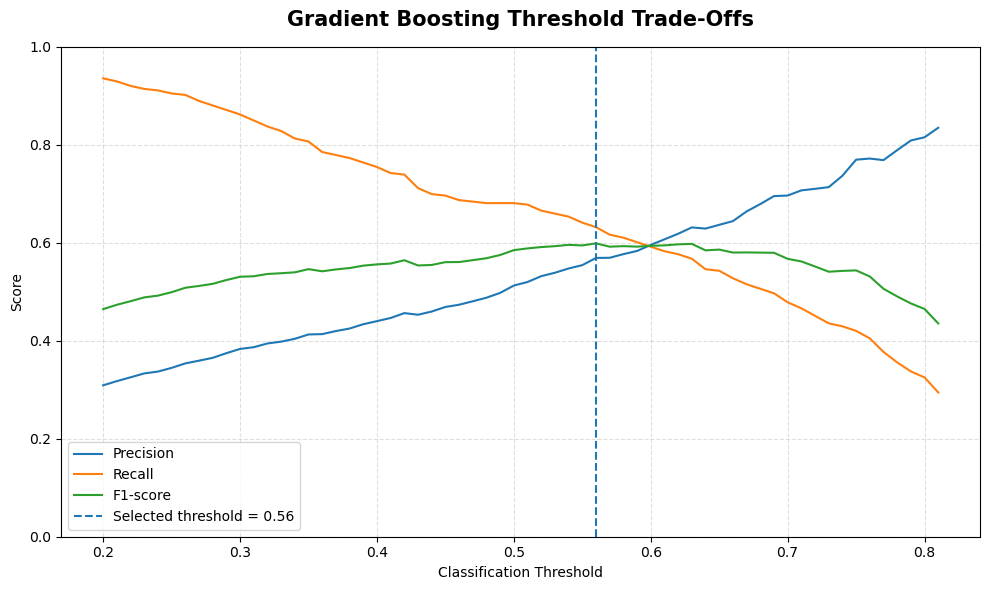

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    threshold_comparison["Threshold"],
    threshold_comparison["Precision_Churn"],
    label="Precision"
)

ax.plot(
    threshold_comparison["Threshold"],
    threshold_comparison["Recall_Churn"],
    label="Recall"
)

ax.plot(
    threshold_comparison["Threshold"],
    threshold_comparison["F1_Churn"],
    label="F1-score"
)

ax.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_threshold:.2f}"
)

ax.set_title(
    "Gradient Boosting Threshold Trade-Offs",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.legend()
ax.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "44_gradient_boosting_threshold_tradeoffs.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
final_candidate_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_candidate_model.fit(
    X_train_smote,
    y_train_smote
)

print("Final candidate model trained on full SMOTE-balanced training data.")

Final candidate model trained on full SMOTE-balanced training data.


In [44]:
final_test_probabilities = (
    final_candidate_model
    .predict_proba(X_test)[:, 1]
)

final_test_predictions_default = (
    final_test_probabilities >= 0.50
).astype(int)

final_test_predictions_tuned = (
    final_test_probabilities >= best_threshold
).astype(int)

print("Default and tuned-threshold predictions created.")

Default and tuned-threshold predictions created.


In [45]:
def evaluate_threshold_predictions(
    threshold_name,
    threshold_value,
    predictions,
    probabilities
):
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "Threshold_Name": threshold_name,
        "Threshold": threshold_value,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "Precision_Churn": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall_Churn": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1_Churn": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probabilities
        ),
        "True_Negatives": int(tn),
        "False_Positives": int(fp),
        "False_Negatives": int(fn),
        "True_Positives": int(tp)
    }


final_threshold_results = [
    evaluate_threshold_predictions(
        threshold_name="Default",
        threshold_value=0.50,
        predictions=final_test_predictions_default,
        probabilities=final_test_probabilities
    ),

    evaluate_threshold_predictions(
        threshold_name="Validation Tuned",
        threshold_value=best_threshold,
        predictions=final_test_predictions_tuned,
        probabilities=final_test_probabilities
    )
]

final_threshold_comparison = pd.DataFrame(
    final_threshold_results
)

final_threshold_comparison[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision_Churn",
        "Recall_Churn",
        "F1_Churn",
        "ROC_AUC",
        "PR_AUC"
    ]
] = final_threshold_comparison[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision_Churn",
        "Recall_Churn",
        "F1_Churn",
        "ROC_AUC",
        "PR_AUC"
    ]
].round(4)

final_threshold_comparison

,Threshold_Name,Threshold,Accuracy,Balanced_Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Default,0.50,0.8130,0.7738,0.5304,0.7076,0.6063,0.8612,0.6978,1338,255,119,288
1,Validation Tuned,0.56,0.8365,0.7711,0.5873,0.6609,0.6220,0.8612,0.6978,1404,189,138,269


In [46]:
final_threshold_comparison.to_csv(
    table_directory /
    "final_threshold_test_comparison.csv",
    index=False
)

print("Final threshold comparison saved.")

Final threshold comparison saved.


In [47]:
final_predictions = (
    final_test_predictions_tuned
)

final_probabilities = (
    final_test_probabilities
)

final_tn, final_fp, final_fn, final_tp = (
    confusion_matrix(
        y_test,
        final_predictions,
        labels=[0, 1]
    ).ravel()
)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        final_predictions
    )
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

final_pr_auc = average_precision_score(
    y_test,
    final_probabilities
)

print("=" * 70)
print("FINAL TUNED MODEL — TEST PERFORMANCE")
print("=" * 70)

print("Model              : SMOTE Gradient Boosting")
print(f"Threshold          : {best_threshold:.2f}")
print(f"Accuracy           : {final_accuracy:.4f}")
print(
    f"Balanced Accuracy  : "
    f"{final_balanced_accuracy:.4f}"
)
print(
    f"Precision - Churn  : "
    f"{final_precision:.4f}"
)
print(
    f"Recall - Churn     : "
    f"{final_recall:.4f}"
)
print(
    f"F1 - Churn         : "
    f"{final_f1:.4f}"
)
print(f"ROC-AUC            : {final_roc_auc:.4f}")
print(f"PR-AUC             : {final_pr_auc:.4f}")

print("\nConfusion Matrix Values")
print(f"True Negatives     : {final_tn}")
print(f"False Positives    : {final_fp}")
print(f"False Negatives    : {final_fn}")
print(f"True Positives     : {final_tp}")

FINAL TUNED MODEL — TEST PERFORMANCE
Model              : SMOTE Gradient Boosting
Threshold          : 0.56
Accuracy           : 0.8365
Balanced Accuracy  : 0.7711
Precision - Churn  : 0.5873
Recall - Churn     : 0.6609
F1 - Churn         : 0.6220
ROC-AUC            : 0.8612
PR-AUC             : 0.6978

Confusion Matrix Values
True Negatives     : 1404
False Positives    : 189
False Negatives    : 138
True Positives     : 269


In [48]:
final_classification_report = classification_report(
    y_test,
    final_predictions,
    target_names=[
        "Retained",
        "Churned"
    ],
    output_dict=True,
    zero_division=0
)

final_classification_report_df = (
    pd.DataFrame(
        final_classification_report
    )
    .T
    .round(4)
)

final_classification_report_df

,precision,recall,f1-score,support
Retained,0.9105,0.8814,0.8957,1593.0000
Churned,0.5873,0.6609,0.6220,407.0000
accuracy,0.8365,0.8365,0.8365,0.8365
macro avg,0.7489,0.7711,0.7588,2000.0000
weighted avg,0.8447,0.8365,0.8400,2000.0000


In [49]:
final_classification_report_df.to_csv(
    table_directory /
    "final_model_classification_report.csv"
)

print("Final classification report saved.")

Final classification report saved.


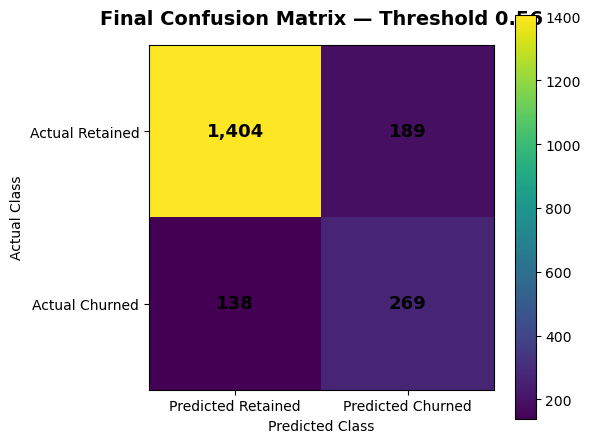

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\45_final_tuned_model_confusion_matrix.png


In [50]:
final_confusion_matrix = confusion_matrix(
    y_test,
    final_predictions,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(6, 5))

matrix_image = ax.imshow(
    final_confusion_matrix
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted Retained",
    "Predicted Churned"
])

ax.set_yticklabels([
    "Actual Retained",
    "Actual Churned"
])

for row_index in range(2):
    for column_index in range(2):
        ax.text(
            column_index,
            row_index,
            f"{final_confusion_matrix[row_index, column_index]:,}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

ax.set_title(
    (
        "Final Confusion Matrix — "
        f"Threshold {best_threshold:.2f}"
    ),
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

fig.colorbar(
    matrix_image,
    ax=ax
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "45_final_tuned_model_confusion_matrix.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [51]:
final_model_path = (
    model_directory /
    "final_smote_gradient_boosting.pkl"
)

joblib.dump(
    final_candidate_model,
    final_model_path
)

threshold_path = (
    model_directory /
    "final_classification_threshold.json"
)

threshold_metadata = {
    "model_name": "SMOTE Gradient Boosting",
    "classification_threshold": float(
        best_threshold
    ),
    "threshold_selection_method": (
        "Maximum validation F1-score"
    ),
    "random_state": 42,
    "feature_count": int(
        X_train.shape[1]
    ),
    "feature_names": list(
        X_train.columns
    )
}

with open(
    threshold_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        threshold_metadata,
        file,
        indent=4
    )

print(f"Final model saved to:\n{final_model_path}")
print(f"\nThreshold metadata saved to:\n{threshold_path}")

Final model saved to:
d:\Customer_Segmentation_Churn_Banking\models\final_smote_gradient_boosting.pkl

Threshold metadata saved to:
d:\Customer_Segmentation_Churn_Banking\models\final_classification_threshold.json


In [52]:
final_prediction_output = pd.DataFrame({
    "Actual_Exited": y_test.reset_index(
        drop=True
    ),
    "Churn_Probability": final_probabilities,
    "Predicted_Exited": final_predictions
})

final_prediction_output[
    "Prediction_Status"
] = np.where(
    final_prediction_output[
        "Predicted_Exited"
    ] == 1,
    "Predicted Churn",
    "Predicted Retained"
)

final_prediction_output.to_csv(
    processed_directory /
    "final_test_predictions.csv",
    index=False
)

final_prediction_output.head()

,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction_Status
0,0,0.051137,0,Predicted Retained
1,0,0.197260,0,Predicted Retained
2,0,0.169798,0,Predicted Retained
3,0,0.113600,0,Predicted Retained
4,0,0.236320,0,Predicted Retained


In [53]:
print("=" * 70)
print("FINAL MODEL ARTIFACT VERIFICATION")
print("=" * 70)

print(
    f"Final model exists       : "
    f"{final_model_path.exists()}"
)

print(
    f"Threshold metadata exists: "
    f"{threshold_path.exists()}"
)

print(
    f"Prediction file exists   : "
    f"{(
        processed_directory /
        'final_test_predictions.csv'
    ).exists()}"
)

print(
    f"Model feature count      : "
    f"{len(X_train.columns)}"
)

print(
    f"Selected threshold       : "
    f"{best_threshold:.2f}"
)

print("\nNotebook 05 completed successfully.")

FINAL MODEL ARTIFACT VERIFICATION
Final model exists       : True
Threshold metadata exists: True
Prediction file exists   : True
Model feature count      : 17
Selected threshold       : 0.56

Notebook 05 completed successfully.
